In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pickle

import gpjax as gpx
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from gpjax.kernels import RBF, Linear, Matern12, Periodic

from gallifrey.gps import KernelSearch, kernel_summary, predictive_distribution
from gallifrey.transit import example_lightcurve
from gallifrey.util import plot_masks, plot_prediction

In [ ]:
plt.style.use("../figures/gpjax.mplstyle")
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

# CREATE TOY DATA

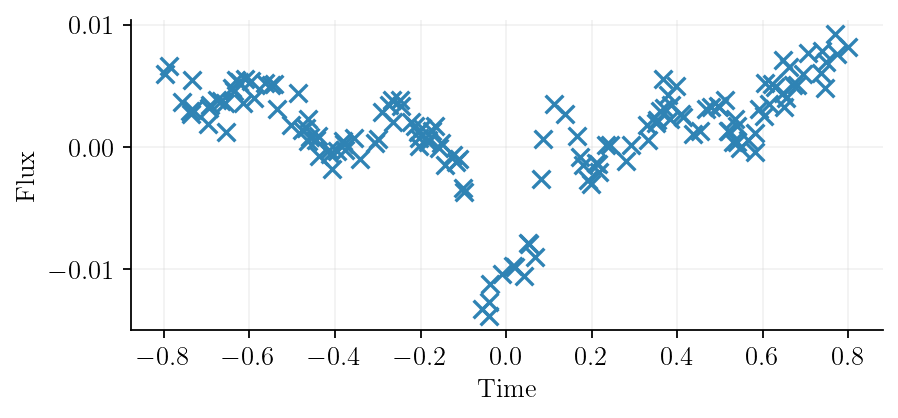

In [10]:
example = example_lightcurve()

name = "test_data" if example["phi"] == 0 else "test_data_ar_noise"
plt.scatter(example["t_sample"], example["lc_sample"])
plt.ylabel("Flux")
plt.xlabel("Time")
plt.savefig(f"../figures/001_kernelsearch/{name}.pdf")

## PERFORM KERNEL SEARCH

In [ ]:
model_name = example["name"]
mode = "lod"

In [ ]:
kernel_library = [
    Linear(),
    RBF(),
    Matern12(),
    Periodic(),
]

In [ ]:
if mode == "load":
    with open(f"../data/processed/toy_data/gp_models/{model_name}", "rb") as file:
        model = pickle.load(file)
else:
    tree = KernelSearch(
        kernel_library,
        X=jnp.array(example["t_sample"][example["transit_mask_sample"]]),
        y=jnp.array(example["lc_sample"][example["transit_mask_sample"]]),
        obs_stddev=example["noise_std"],
        verbosity=1,
        num_threads=8,
    )

    model = tree.search(
        depth=7,
        n_leafs=4,
        patience=1,
    ).posterior
    if mode == "save":
        with open(f"../data/processed/toy_data/gp_models/{model_name}", "wb") as file:
            pickle.dump(model, file)

summary = kernel_summary(model, to_latex=False)

## PLOT GP PREDICTION

In [ ]:
# calculate predictive distribution
dist = predictive_distribution(
    model,
    example["t"],
    X=example["t_sample"][example["transit_mask_sample"]],
    y=example["lc_sample"][example["transit_mask_sample"]],
)

In [ ]:
fig, ax = plt.subplots()
ax.scatter(
    example["t_sample"], example["lc_sample"], label="Data", color=cols[0], alpha=0.5
)

for data, label, linestyle in [
    (example["transit"] + example["background"], "Transit + Background", "--"),
    (example["background"], "Background", "-"),
]:
    ax.plot(
        example["t"],
        data,
        label=label,
        color=cols[0],
        linestyle=linestyle,
        linewidth=2,
    )

ax = plot_prediction(ax, example["t"], dist, errorbar=1, kws_mean={"color": cols[1]})
ax = plot_masks(ax, example["t"], example["transit_mask"])

ax.set_ylabel(r"Flux - $\langle \mathrm{Flux} \rangle$")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0, 0.28))
fig.savefig("../figures/001_kernelsearch/gp_fit.pdf")

## PLOT KERNEL CONTRIBUTIONS

In [ ]:
fig, ax = plt.subplots()

for i, kernel in enumerate(model.prior.kernel.kernels):  # type: ignore
    component_model = model.likelihood * gpx.gps.Prior(
        mean_function=model.prior.mean_function,
        kernel=kernel,
    )

    component_dist = predictive_distribution(
        component_model,
        example["t"],
        x=example["t_sample"][example["transit_mask_sample"]],
        y=example["lc_sample"][example["transit_mask_sample"]],
    )

    ax = plot_prediction(
        ax,
        example["t"],
        component_dist,
        errorbar=1,
        kws_mean={
            "color": cols[i],
            "label": kernel_summary(
                component_model, short=True, silence=True, to_latex=True
            ),
        },
        kws_error={"label": None},
    )

ax.set_ylabel("Kernel Flux Contribution")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0.0, 0.07), ncols=4)
fig.savefig("../figures/001_kernelsearch/gp_fit_decompostion.pdf")